In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
import cv2
import matplotlib.pyplot as plt

# Paths
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks/"
img_size = (128, 128)  # Resize all images to this shape for the model


def load_data(folder, size):
    data = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, size)
            img = img / 255.0  # Normalize
            data.append(img)
    return np.array(data)

# Load images and masks
images = load_data(image_folder, img_size)
masks = load_data(mask_folder, img_size)

# Ensure masks are binary
masks = (masks[..., 0] > 0.5).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

In [3]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Compute Dice coefficient for binary segmentation
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    
    return (2. * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    """
    Dice loss function
    """
    return 1 - dice_coefficient(y_true, y_pred)

def unet_plus_plus_model(input_shape, dropout_rate=0.1):
    """
    UNet++ architecture with nested skip connections
    """
    inputs = Input(shape=input_shape)
    
    # Initial feature maps
    X0_0 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    X0_0 = BatchNormalization()(X0_0)
    X0_0 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_0)
    X0_0 = BatchNormalization()(X0_0)
    
    # Downsampling path with nested connections
    P1 = MaxPooling2D((2, 2))(X0_0)
    P1 = Dropout(dropout_rate)(P1)
    
    X1_0 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(P1)
    X1_0 = BatchNormalization()(X1_0)
    X1_0 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X1_0)
    X1_0 = BatchNormalization()(X1_0)
    
    # Nested skip connections
    X0_1 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(X1_0)
    X0_1 = concatenate([X0_1, X0_0])
    X0_1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_1)
    X0_1 = BatchNormalization()(X0_1)
    X0_1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_1)
    X0_1 = BatchNormalization()(X0_1)
    
    # Continue downsampling
    P2 = MaxPooling2D((2, 2))(X1_0)
    P2 = Dropout(dropout_rate)(P2)
    
    X2_0 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(P2)
    X2_0 = BatchNormalization()(X2_0)
    X2_0 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X2_0)
    X2_0 = BatchNormalization()(X2_0)
    
    # More nested connections
    X1_1 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(X2_0)
    X1_1 = concatenate([X1_1, X1_0])
    X1_1 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X1_1)
    X1_1 = BatchNormalization()(X1_1)
    X1_1 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X1_1)
    X1_1 = BatchNormalization()(X1_1)
    
    X0_2 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(X1_1)
    X0_2 = concatenate([X0_2, X0_0, X0_1])
    X0_2 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_2)
    X0_2 = BatchNormalization()(X0_2)
    X0_2 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_2)
    X0_2 = BatchNormalization()(X0_2)
    
    # Bottleneck
    P3 = MaxPooling2D((2, 2))(X2_0)
    P3 = Dropout(dropout_rate*2)(P3)
    
    X3_0 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(P3)
    X3_0 = BatchNormalization()(X3_0)
    X3_0 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X3_0)
    X3_0 = BatchNormalization()(X3_0)
    
    # Upsampling and additional nested connections
    X2_1 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(X3_0)
    X2_1 = concatenate([X2_1, X2_0])
    X2_1 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X2_1)
    X2_1 = BatchNormalization()(X2_1)
    X2_1 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X2_1)
    X2_1 = BatchNormalization()(X2_1)
    
    X1_2 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(X2_1)
    X1_2 = concatenate([X1_2, X1_0, X1_1])
    X1_2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X1_2)
    X1_2 = BatchNormalization()(X1_2)
    X1_2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X1_2)
    X1_2 = BatchNormalization()(X1_2)
    
    X0_3 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(X1_2)
    X0_3 = concatenate([X0_3, X0_0, X0_1, X0_2])
    X0_3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_3)
    X0_3 = BatchNormalization()(X0_3)
    X0_3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(X0_3)
    X0_3 = BatchNormalization()(X0_3)
    
    # Output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(X0_3)
    
    # Create model
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

def train_water_body_detection_model(X_train, y_train, X_val, y_val, img_size, batch_size=8, epochs=50):
    # Create and compile UNet++ model
    model = unet_plus_plus_model(input_shape=(img_size[0], img_size[1], 3))
    
    # Use Adam optimizer with lower learning rate
    optimizer = Adam(learning_rate=1e-4)
    
    # Compile with Dice loss and additional metrics
    model.compile(
        optimizer=optimizer,
        loss=[dice_loss],  # Using Dice loss instead of binary cross-entropy
        metrics=['accuracy', 
                 tf.keras.metrics.Recall(), 
                 tf.keras.metrics.Precision(), 
                 tf.keras.metrics.MeanIoU(num_classes=2)]
    )
    
    # Define callbacks
    callbacks = [
        ModelCheckpoint(
            "unet_plus_plus_water_body_best_model.h5", 
            save_best_only=True,
            monitor='val_mean_io_u',
            mode='max'
        ),
        EarlyStopping(
            patience=10,
            monitor='val_mean_io_u',
            mode='max',
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        )
    ]
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )
    
    # Save final model
    model.save("unet_plus_plus_water_body_detection_final.h5")
    
    return model, history

# The plot_training_history and visualize_predictions functions remain the same as in the original code

In [5]:
model, history = train_water_body_detection_model(X_train, y_train, X_val, y_val, img_size)
    


Epoch 1/50


C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7709 - loss: 0.3476 - mean_io_u: 0.3523 - precision: 0.6004 - recall: 0.7689

C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(8, 128, 128, 3))
  warnings.warn(msg)


272/272 ━━━━━━━━━━━━━━━━━━━━ 1208s 4s/step - accuracy: 0.7710 - loss: 0.3474 - mean_io_u: 0.3524 - precision: 0.6006 - recall: 0.7689 - val_accuracy: 0.5580 - val_loss: 0.4696 - val_mean_io_u: 0.5976 - val_precision: 0.3909 - val_recall: 0.8746 - learning_rate: 1.0000e-04
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1072s 4s/step - accuracy: 0.8586 - loss: 0.2459 - mean_io_u: 0.4275 - precision: 0.7466 - recall: 0.7846 - val_accuracy: 0.8696 - val_loss: 0.2174 - val_mean_io_u: 0.5416 - val_precision: 0.7496 - val_recall: 0.8423 - learning_rate: 1.0000e-04
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1057s 4s/step - accuracy: 0.8665 - loss: 0.2253 - mean_io_u: 0.4713 - precision: 0.7688 - recall: 0.7949 - val_accuracy: 0.8954 - val_loss: 0.1851 - val_mean_io_u: 0.4956 - val_precision: 0.8174 - val_recall: 0.8341 - learning_rate: 1.0000e-04
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8793 - loss: 0.2051 - mean_io_u: 0.5213 - precision: 0.7918 - recall: 0.8075

...

272/272 ━━━━━━━━━━━━━━━━━━━━ 1062s 4s/step - accuracy: 0.8914 - loss: 0.1843 - mean_io_u: 0.5807 - precision: 0.8186 - recall: 0.8204 - val_accuracy: 0.9098 - val_loss: 0.1592 - val_mean_io_u: 0.7487 - val_precision: 0.8472 - val_recall: 0.8493 - learning_rate: 1.0000e-04
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1066s 4s/step - accuracy: 0.8991 - loss: 0.1727 - mean_io_u: 0.6316 - precision: 0.8274 - recall: 0.8345 - val_accuracy: 0.9093 - val_loss: 0.1609 - val_mean_io_u: 0.6054 - val_precision: 0.8474 - val_recall: 0.8473 - learning_rate: 1.0000e-04
Epoch 9/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9031 - loss: 0.1688 - mean_io_u: 0.6389 - precision: 0.8398 - recall: 0.8306

272/272 ━━━━━━━━━━━━━━━━━━━━ 1065s 4s/step - accuracy: 0.9031 - loss: 0.1688 - mean_io_u: 0.6389 - precision: 0.8397 - recall: 0.8306 - val_accuracy: 0.9088 - val_loss: 0.1583 - val_mean_io_u: 0.7637 - val_precision: 0.8387 - val_recall: 0.8578 - learning_rate: 1.0000e-04
Epoch 10/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1060s 4s/step - accuracy: 0.9022 - loss: 0.1719 - mean_io_u: 0.6347 - precision: 0.8333 - recall: 0.8324 - val_accuracy: 0.9058 - val_loss: 0.1674 - val_mean_io_u: 0.6309 - val_precision: 0.8433 - val_recall: 0.8384 - learning_rate: 1.0000e-04
Epoch 11/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1075s 4s/step - accuracy: 0.9058 - loss: 0.1630 - mean_io_u: 0.6242 - precision: 0.8431 - recall: 0.8386 - val_accuracy: 0.9059 - val_loss: 0.1602 - val_mean_io_u: 0.7378 - val_precision: 0.8188 - val_recall: 0.8771 - learning_rate: 1.0000e-04
Epoch 12/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1060s 4s/step - accuracy: 0.9047 - loss: 0.1614 - mean_io_u: 0.6637 - precision: 0.8442 - recall: 0.8405 - val_accur

272/272 ━━━━━━━━━━━━━━━━━━━━ 1070s 4s/step - accuracy: 0.9068 - loss: 0.1592 - mean_io_u: 0.6710 - precision: 0.8407 - recall: 0.8462 - val_accuracy: 0.9050 - val_loss: 0.1674 - val_mean_io_u: 0.7726 - val_precision: 0.8306 - val_recall: 0.8542 - learning_rate: 1.0000e-04
Epoch 14/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1063s 4s/step - accuracy: 0.9106 - loss: 0.1549 - mean_io_u: 0.6684 - precision: 0.8521 - recall: 0.8438 - val_accuracy: 0.9117 - val_loss: 0.1536 - val_mean_io_u: 0.7461 - val_precision: 0.8305 - val_recall: 0.8826 - learning_rate: 1.0000e-04
Epoch 15/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1061s 4s/step - accuracy: 0.9121 - loss: 0.1542 - mean_io_u: 0.6908 - precision: 0.8612 - recall: 0.8399 - val_accuracy: 0.9157 - val_loss: 0.1520 - val_mean_io_u: 0.7196 - val_precision: 0.8616 - val_recall: 0.8532 - learning_rate: 1.0000e-04
Epoch 16/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1064s 4s/step - accuracy: 0.9103 - loss: 0.1534 - mean_io_u: 0.6870 - precision: 0.8634 - recall: 0.8339 - val_accur

272/272 ━━━━━━━━━━━━━━━━━━━━ 1070s 4s/step - accuracy: 0.9247 - loss: 0.1320 - mean_io_u: 0.7104 - precision: 0.8849 - recall: 0.8585 - val_accuracy: 0.9185 - val_loss: 0.1434 - val_mean_io_u: 0.7918 - val_precision: 0.8575 - val_recall: 0.8701 - learning_rate: 1.0000e-04
Epoch 23/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1055s 4s/step - accuracy: 0.9222 - loss: 0.1358 - mean_io_u: 0.7204 - precision: 0.8843 - recall: 0.8511 - val_accuracy: 0.9213 - val_loss: 0.1406 - val_mean_io_u: 0.7823 - val_precision: 0.8721 - val_recall: 0.8611 - learning_rate: 1.0000e-04
Epoch 24/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1070s 4s/step - accuracy: 0.9237 - loss: 0.1323 - mean_io_u: 0.7173 - precision: 0.8840 - recall: 0.8576 - val_accuracy: 0.9201 - val_loss: 0.1428 - val_mean_io_u: 0.7599 - val_precision: 0.8705 - val_recall: 0.8585 - learning_rate: 1.0000e-04
Epoch 25/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1055s 4s/step - accuracy: 0.9296 - loss: 0.1215 - mean_io_u: 0.7255 - precision: 0.8867 - recall: 0.8746 - val_accur

NameError: name 'plot_training_history' is not defined

In [9]:
# Function to plot training history with additional metrics
def plot_training_history(history):
    # Create a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot accuracy
    axs[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0, 0].set_title('Model Accuracy')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend(loc='lower right')
    
    # Plot loss
    axs[0, 1].plot(history.history['loss'], label='Training Loss')
    axs[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axs[0, 1].set_title('Model Loss')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend(loc='upper right')
    
    # Plot IoU
    axs[1, 0].plot(history.history['mean_io_u'], label='Training IoU')
    axs[1, 0].plot(history.history['val_mean_io_u'], label='Validation IoU')
    axs[1, 0].set_title('Mean IoU')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('IoU')
    axs[1, 0].legend(loc='lower right')
    
    # Plot Precision-Recall
    axs[1, 1].plot(history.history['precision'], label='Training Precision')
    axs[1, 1].plot(history.history['val_precision'], label='Validation Precision')
    axs[1, 1].plot(history.history['recall'], label='Training Recall')
    axs[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axs[1, 1].set_title('Precision and Recall')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('training_history_plus.png')
    plt.show()

# Function to visualize prediction results
def visualize_predictions(model, X_test, y_test, num_samples=5):
    # Get predictions
    y_pred = model.predict(X_test[:num_samples])
    
    # Create figure
    fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples*5))
    
    for i in range(num_samples):
        # Display original image
        axs[i, 0].imshow(X_test[i])
        axs[i, 0].set_title('Original Image')
        axs[i, 0].axis('off')
        
        # Display ground truth mask
        axs[i, 1].imshow(y_test[i].squeeze(), cmap='gray')
        axs[i, 1].set_title('Ground Truth')
        axs[i, 1].axis('off')
        
        # Display predicted mask
        axs[i, 2].imshow(y_pred[i].squeeze(), cmap='gray')
        axs[i, 2].set_title('Prediction')
        axs[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_results.png')
    plt.show()

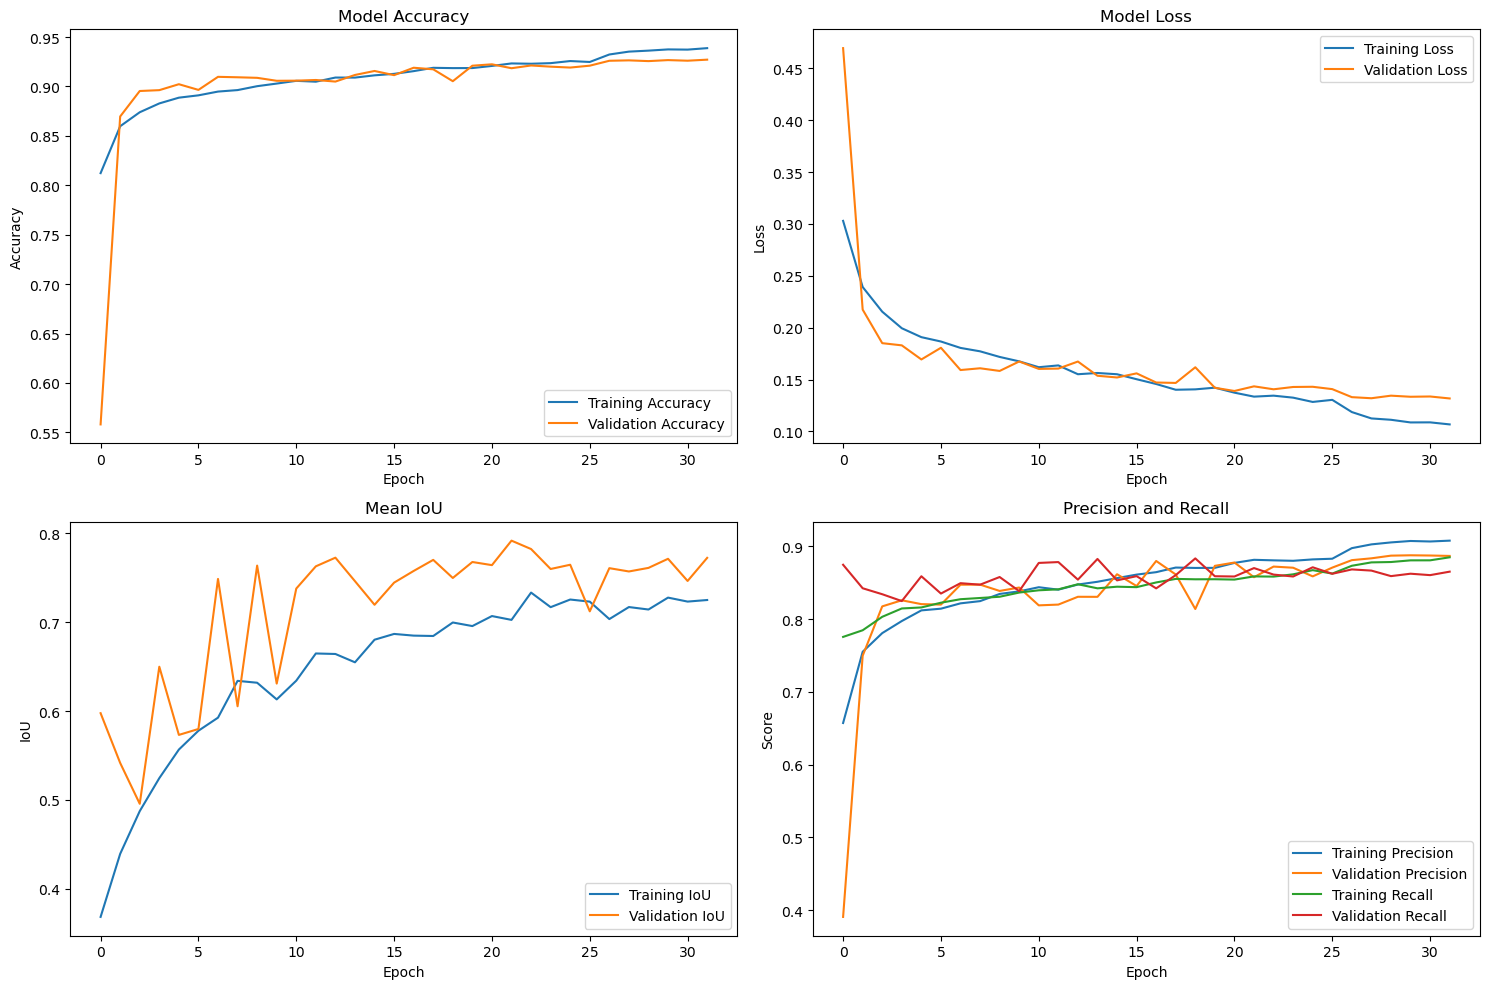

In [11]:
    # Plot training history
plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


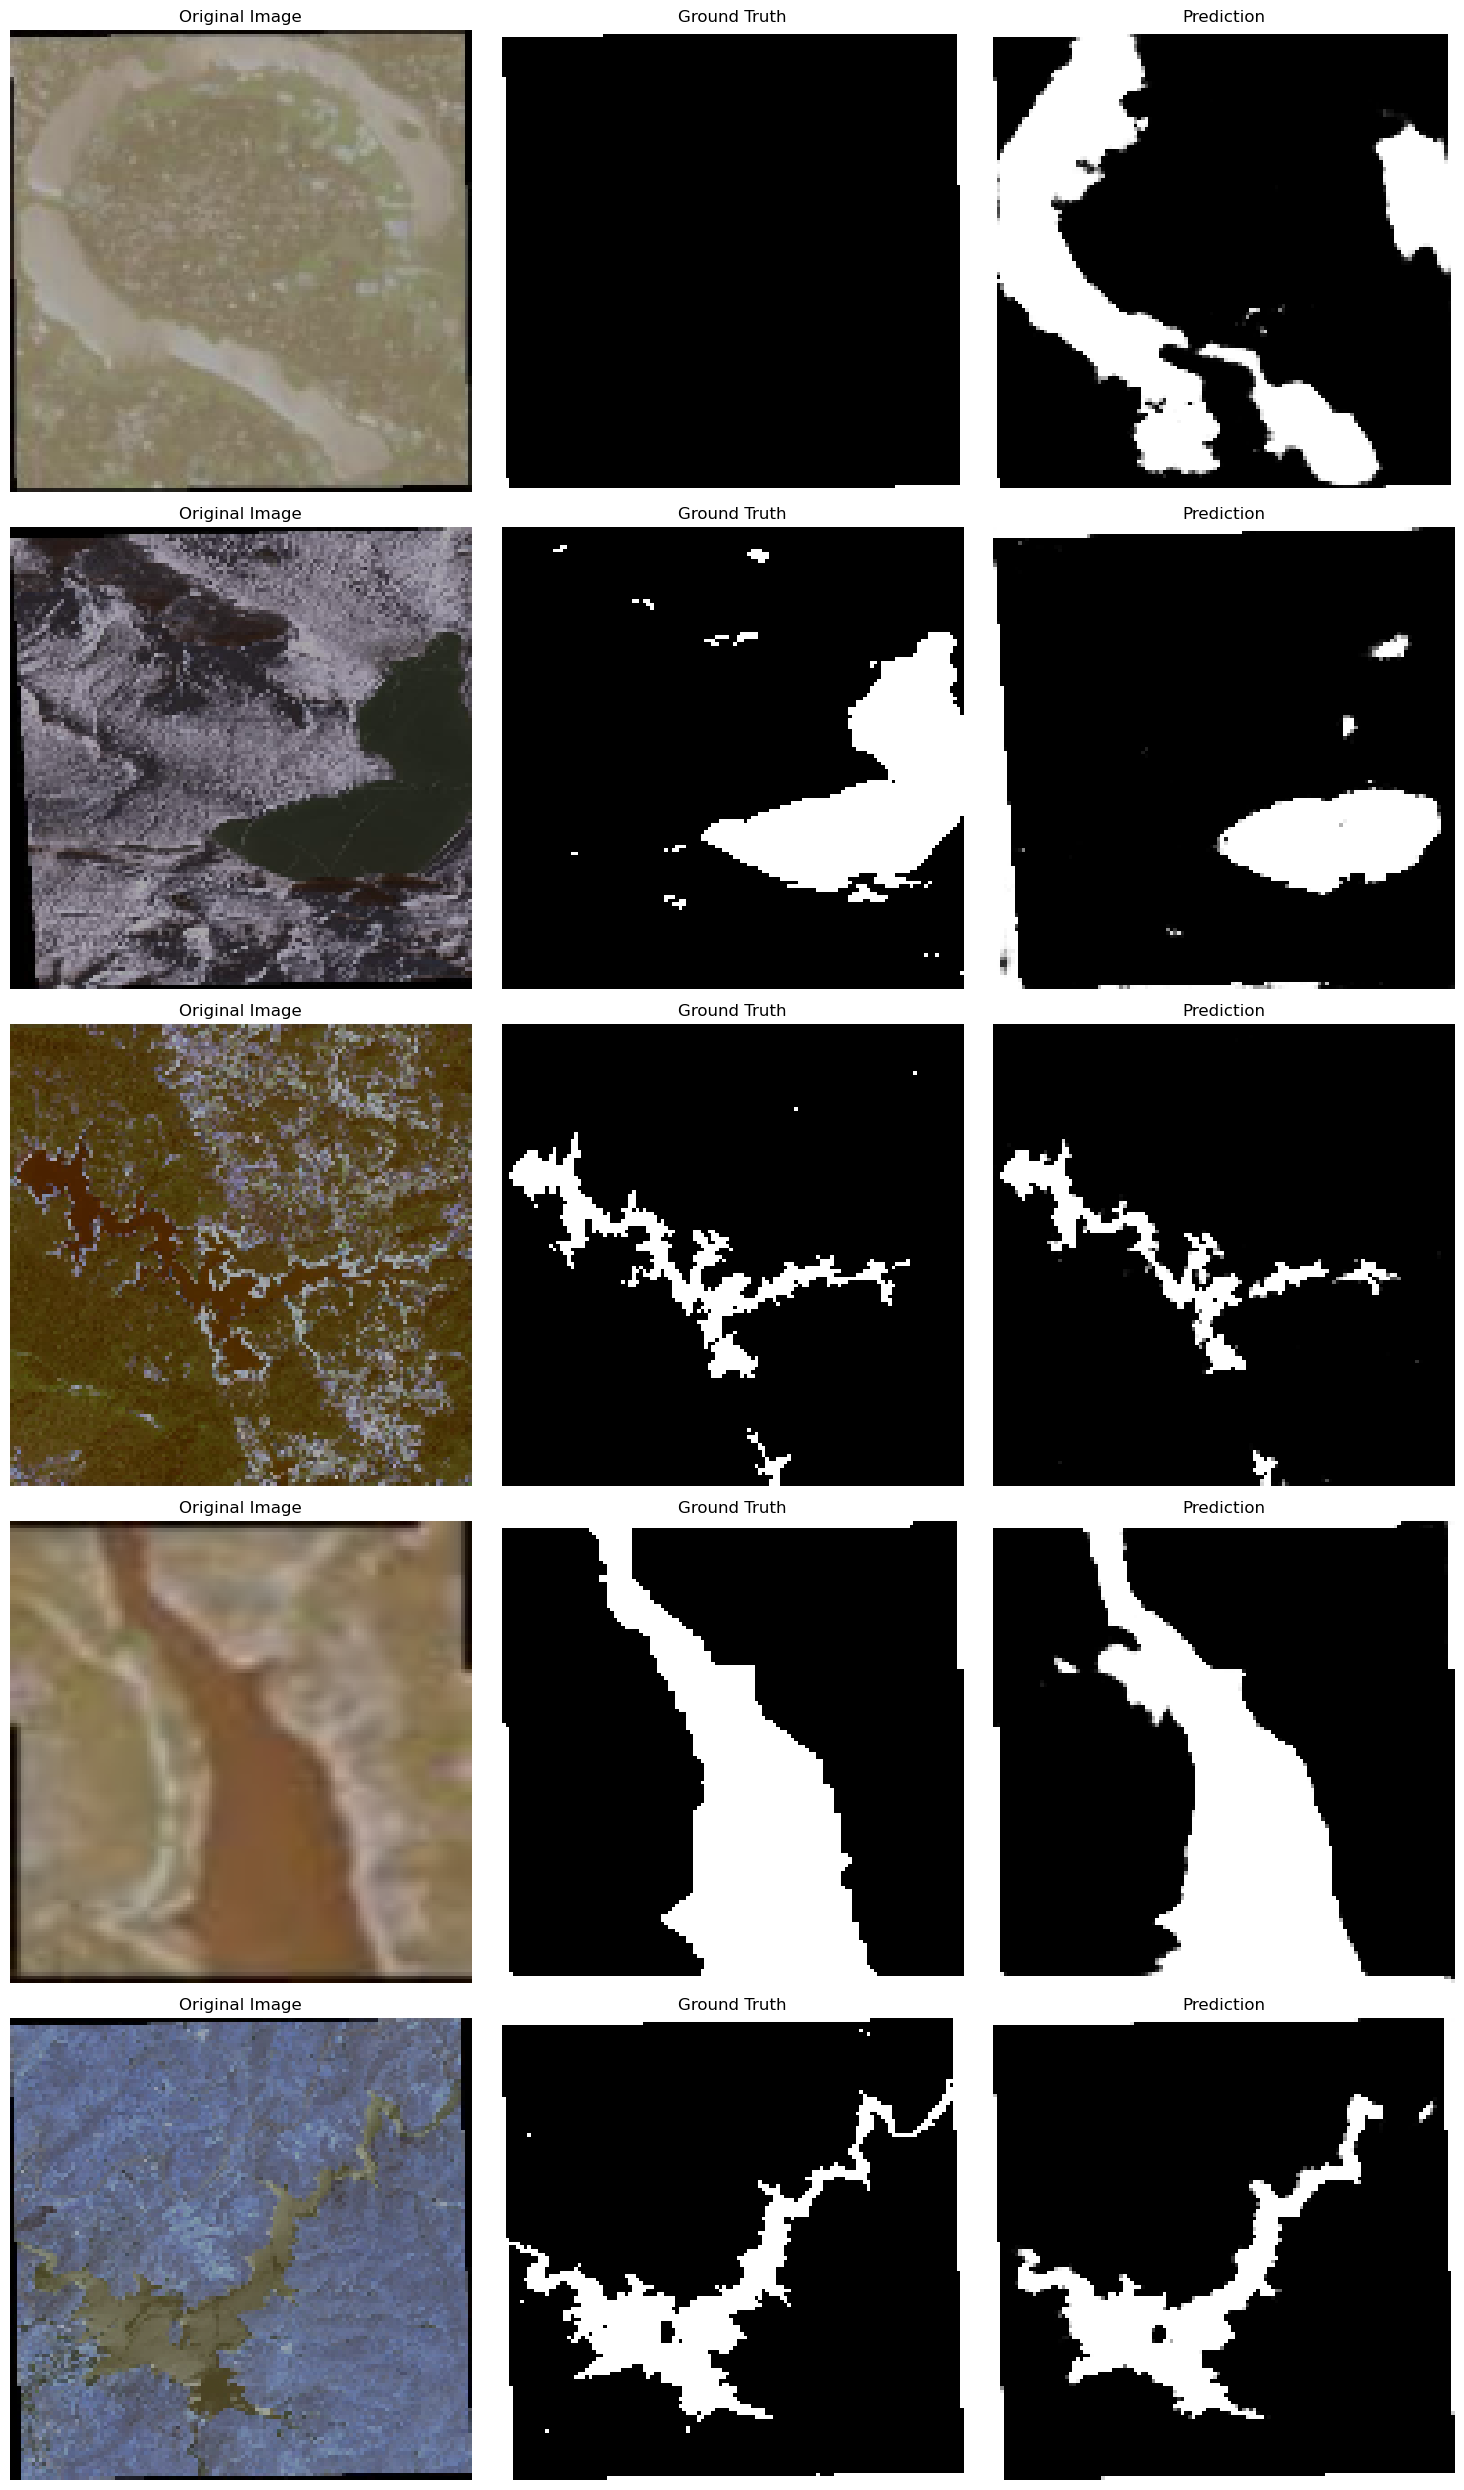

In [15]:
visualize_predictions(model, X_val, y_val, num_samples=5)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_7[0][0]  

 Total params: 29,793,349 (113.65 MB)

 Trainable params: 9,928,897 (37.88 MB)

 Non-trainable params: 6,656 (26.00 KB)

 Optimizer params: 19,857,796 (75.75 MB)

### Testing ###

In [2]:
from tensorflow.keras.models import load_model

model = load_model("unet_plus_plus_water_body_detection_final.h5", compile=False)  # Set compile=False if you will evaluate manually


In [4]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


In [7]:
import random
import tensorflow as tf
# Load the saved model
model = tf.keras.models.load_model("unet_plus_plus_water_body_detection_final.h5")

# Make predictions on validation images
predictions = model.predict(X_val)

# Threshold the predicted masks
predicted_masks = (predictions > 0.5).astype(np.uint8)



17/17 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step


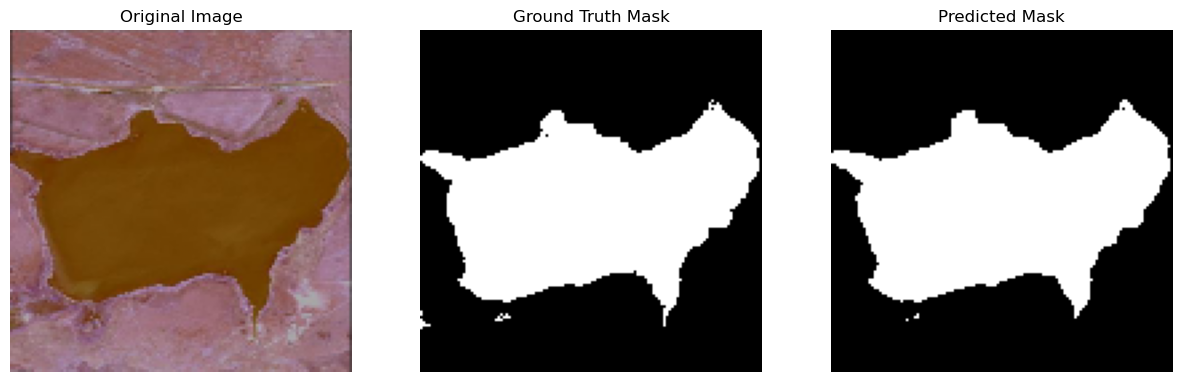

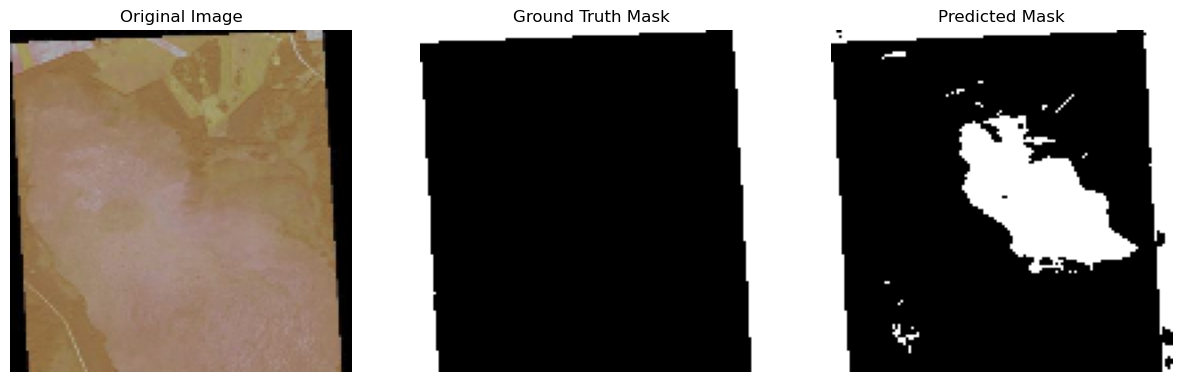

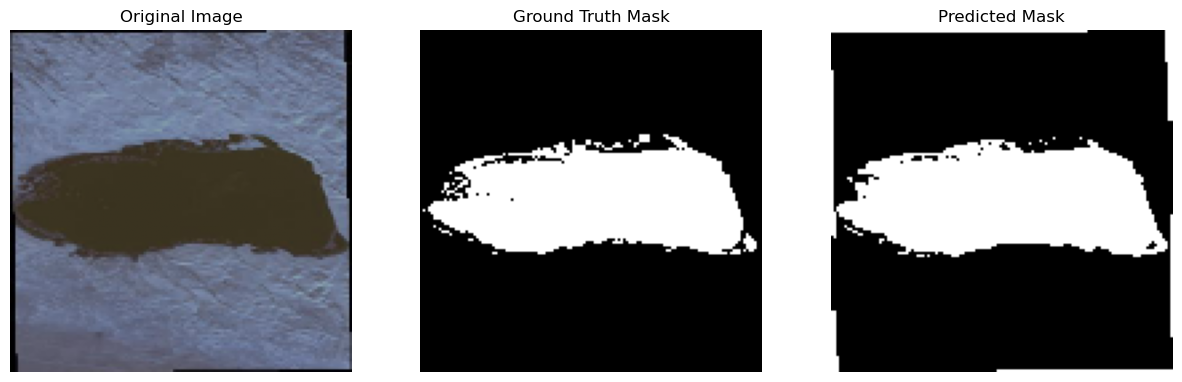

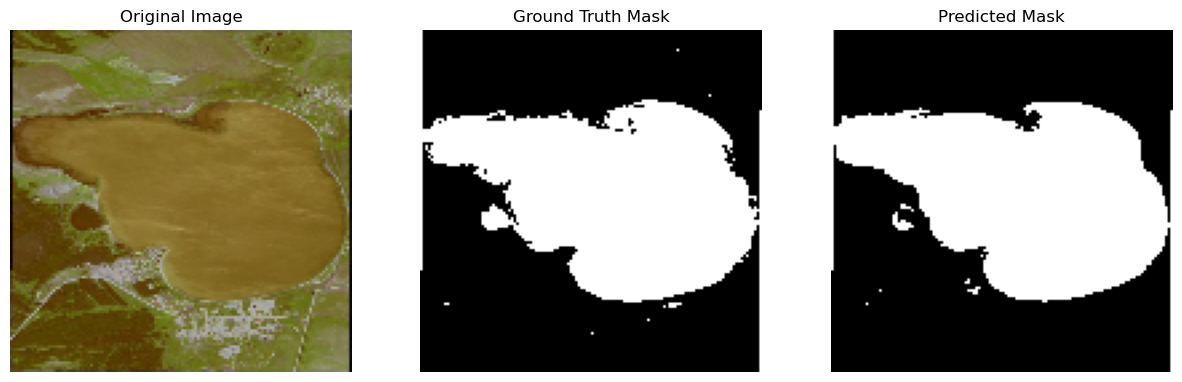

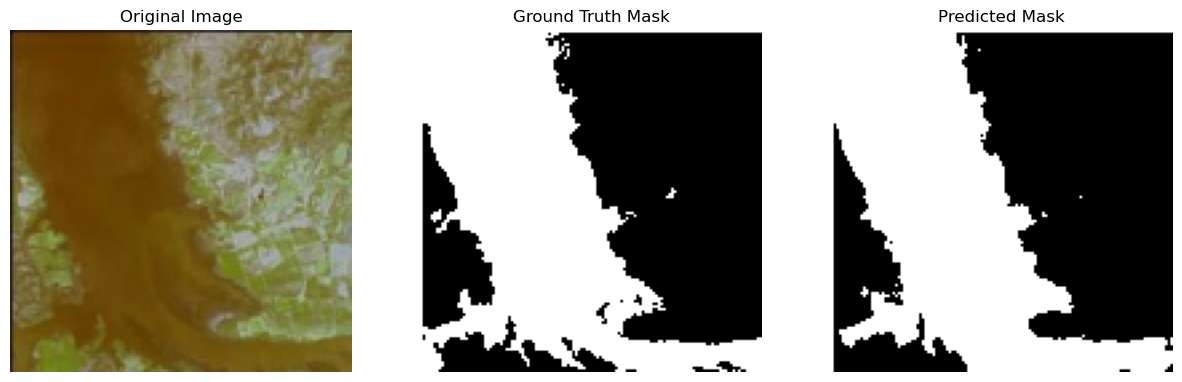

In [15]:
# Select 5 random indices
random_indices = random.sample(range(len(X_val)), 5)

# Plot random predictions alongside original images and ground truth masks
for i, idx in enumerate(random_indices):
    plt.figure(figsize=(15, 5))

    # Original validation image
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[idx])
    plt.title("Original Image")
    plt.axis('off')

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


### There were some images, whose masks were completely blacked out, which we deleted.

In [5]:
import numpy as np
import os
import cv2
mask_folder = "D:/Water Bodies Dataset/Masks/"
mask_files = sorted(os.listdir(mask_folder))
white_mask_count = 0

for mask_file in mask_files:
    mask = cv2.imread(os.path.join(mask_folder, mask_file), cv2.IMREAD_GRAYSCALE)
    if np.all(mask == 255):  # Check if the entire mask is white
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1

print(f"Total completely white masks: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Completely white mask: water_body_1370.jpg
Completely white mask: water_body_1371.jpg
Completely white mask: water_body_1397.jpg
Completely white mask: water_body_15.jpg
Completely white mask: water_body_1552.jpg
Completely white mask: water_body_1553.jpg
Completely white mask: water_body_1562.jpg
Completely white mask: water_body_1606.jpg
Completely white mask: water_body_1607.jpg
Completely white mask: water_body_1616.jpg
Completely white mask: water_body_1619.jpg
Completely white mask: water_body_1621.jpg
Completely white mask: water_body_1659.jpg
Completely white mask: water_body_1661.jpg
Completely wh

In [12]:
import os
import cv2
import numpy as np

# Define the paths for images and masks
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks/"

# Get all mask files (assuming masks are in .jpg format)
mask_files = sorted(os.listdir(mask_folder))

# Initialize counter for white masks
white_mask_count = 0

# Loop through all mask files
for mask_file in mask_files:
    mask_path = os.path.join(mask_folder, mask_file)
    
    # Load the mask as a grayscale image
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Check if the mask is completely white
    if mask is not None and np.all(mask == 255):
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1
        
        # Construct the corresponding image file path
        image_file = mask_file.replace('.jpg', '.jpg')  # Assuming images are in .jpg format
        image_path = os.path.join(image_folder, image_file)
        
        # Delete both the image and mask if both exist
        if os.path.exists(image_path):
            os.remove(image_path)
            print(f"Deleted image: {image_file}")
        
        os.remove(mask_path)
        print(f"Deleted mask: {mask_file}")

# Print the total number of white masks
print(f"Total completely white masks deleted: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Deleted image: water_body_1023.jpg
Deleted mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Deleted image: water_body_1061.jpg
Deleted mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Deleted image: water_body_1225.jpg
Deleted mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Deleted image: water_body_1226.jpg
Deleted mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Deleted image: water_body_1232.jpg
Deleted mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Deleted image: water_body_1244.jpg
Deleted mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Deleted image: water_body_1333.jpg
Deleted mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Deleted image: water_body_1342.jpg
Deleted mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Deleted image: water_body_1364.jpg
Deleted mask: water_body_1

In [22]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib
import os

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("OpenCV (cv2) version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("OS module version: Built-in, no version")  # os is a standard Python module

TensorFlow version: 2.19.0
NumPy version: 1.26.4
OpenCV (cv2) version: 4.11.0
Matplotlib version: 3.9.2
OS module version: Built-in, no version
